In [2]:
import numpy as np
import matplotlib.pyplot as plt
import glob
import cv2
import os
import tqdm
import torch
import json
from kraken import pageseg, binarization
from PIL import Image
from predict import TextRegognizer

In [3]:
from model import CRNN

char2idx, idx2char, width, height, MAX_TEXT_LENGTH = torch.load(
    "/Users/konstantinosperifanos/code/projects/postdoc/code/artifacts/model7/model7_artifacts.pt"
)


# device = torch.device("mps")
device = torch.device("cpu")

model = TextRegognizer(
    device=device,
    width=width,
    height=height,
    num_class=len(idx2char),
    # model_path='../code/artifacts/model6/take3/model6_best_loss_1.283.pt',
    model_path="/Users/konstantinosperifanos/code/projects/postdoc/code/artifacts/model7/best_cpu_model_7.pth",
    idx2char=idx2char,
    char2idx=char2idx,
)

In [4]:
width, height, MAX_TEXT_LENGTH

(760, 80, 69)

In [5]:
def segment(image):
    """
    image: np.array
    """
    # binarize

    if isinstance(image, (np.ndarray, np.generic)):
        image = Image.fromarray(image)

    image = binarization.nlbin(image)
    # segment
    regions = pageseg.segment(image)
    return regions

In [6]:
base_path = "/Users/konstantinosperifanos/Downloads/pages/TODO/ΑΑ"

files = glob.glob(base_path + "/**/*.png", recursive=True)

In [8]:
for file in files:
    print(file)
    
    img = cv2.imread(file)
    sections = segment(img)

    # boxes
    boxes = [
        ((x1, y1, x2, y2), f"line {idx}")
        for idx, (x1, y1, x2, y2) in enumerate(sections["boxes"])
    ]


    # get pages and create a dir per page to store segments 
    page_number = os.path.basename(file).split(".")[0]
    base_dir = os.path.dirname(file)
    out_dir = os.path.join(base_dir, page_number)
    if not os.path.exists(out_dir):
        os.mkdir(out_dir)

    #print( out_dir)
   

    # for all segments, ocr and save 
    for index in tqdm.tqdm(range(len(boxes))):

        x1, y1, x2, y2 = boxes[index][0]
        # print( "coords:", (x1,x2), (y1,y2 ))
        cropped_im = img[y1:y2, x1:x2, :]

        gray_image = cv2.cvtColor(cropped_im, cv2.COLOR_BGR2GRAY)

        #plt.imshow(gray_image, cmap="gray")
        #plt.show()
        out_file = os.path.join(out_dir, f"{index:>03d}.png")
        out_txt = os.path.join(out_dir, f"{index:>03d}.json")

        #print(gray_image.shape)
        #break 
        # write coords
        ocred_text = model.ocr(gray_image)
       
        job = {"coords": [x1, y1, x2, y2], "text": ocred_text}
        json.dump(job, open(out_txt, "w"))

        # write image
        cv2.imwrite(out_file, gray_image)
 
   

/Users/konstantinosperifanos/Downloads/pages/TODO/ΑΑ/Φιλολογική πανδαισία τα υποθαλάσσια άνθη. Ευφύια των αγρίων της Αμερικής. Αίτια και αποτέλεσμα./1_2.png


100%|██████████| 43/43 [00:05<00:00,  8.15it/s]


/Users/konstantinosperifanos/Downloads/pages/TODO/ΑΑ/Φιλολογική πανδαισία τα υποθαλάσσια άνθη. Ευφύια των αγρίων της Αμερικής. Αίτια και αποτέλεσμα./1_1.png


100%|██████████| 45/45 [00:05<00:00,  7.53it/s]


/Users/konstantinosperifanos/Downloads/pages/TODO/ΑΑ/Φιλολογική πανδαισία τα υποθαλάσσια άνθη. Ευφύια των αγρίων της Αμερικής. Αίτια και αποτέλεσμα./0_1.png


...

100%|██████████| 52/52 [00:06<00:00,  7.70it/s]


/Users/konstantinosperifanos/Downloads/pages/TODO/ΑΑ/Η ορειβασία εξεταζομένη υπό υγειινή άποψη/0_2.png


100%|██████████| 48/48 [00:06<00:00,  7.90it/s]


/Users/konstantinosperifanos/Downloads/pages/TODO/ΑΑ/Ο ένας και ο άλλος,Φραγκόπουλος, Θεόφιλος Δ./0.png


100%|██████████| 77/77 [00:09<00:00,  7.99it/s]


In [157]:
np.array(image).shape

(3508, 2481, 3)

In [3]:
from PIL import Image
from surya.detection import batch_text_detection
from surya.layout import batch_layout_detection
from surya.model.detection.segformer import load_model, load_processor
from surya.settings import settings

IMAGE_PATH = "/Users/konstantinosperifanos/Downloads/pages/TODO/ΑΑ/Αλληλογραφία/0.png"
# IMAGE_PATH   = "/Users/konstantinosperifanos/Downloads/pages/TODO/ΑΑ/Η Σωτηρία, εφημερίς πολιτική, φιλολογική και των ειδήσεων, Έτος Α', αριθ.79/0.png"
image = Image.open(IMAGE_PATH)

#image = image.resize( (image.width // 2, image.height // 2), Image.BICUBIC)

model = load_model(checkpoint=settings.LAYOUT_MODEL_CHECKPOINT)
processor = load_processor(checkpoint=settings.LAYOUT_MODEL_CHECKPOINT)
det_model = load_model()
det_processor = load_processor()

# layout_predictions is a list of dicts, one per image
line_predictions = batch_text_detection([image], det_model, det_processor)
layout_predictions = batch_layout_detection([image], model, processor, line_predictions)

ImportError: cannot import name 'computed_field' from 'pydantic' (/Users/konstantinosperifanos/code/venvs/py3/lib/python3.10/site-packages/pydantic/__init__.cpython-310-darwin.so)

In [164]:
im = cv2.imread(IMAGE_PATH)

text_boxes  = [p for p in layout_predictions[0].bboxes if p.label=="Text"]
bboxes = [ b.bbox for b in text_boxes]

bboxes.sort(key = lambda x: (x[1], -x[0]))
bboxes

[[341, 1038, 2335, 3098],
 [145, 1113, 193, 1135],
 [157, 1170, 198, 1194],
 [147, 1296, 201, 1316],
 [150, 1327, 203, 1352],
 [150, 1355, 205, 1382],
 [147, 1500, 205, 1539],
 [145, 1536, 210, 1573],
 [150, 1579, 208, 1607],
 [152, 1689, 205, 1713],
 [142, 1798, 210, 1859],
 [150, 1864, 218, 1888],
 [155, 1894, 208, 1919],
 [155, 1925, 213, 1949]]

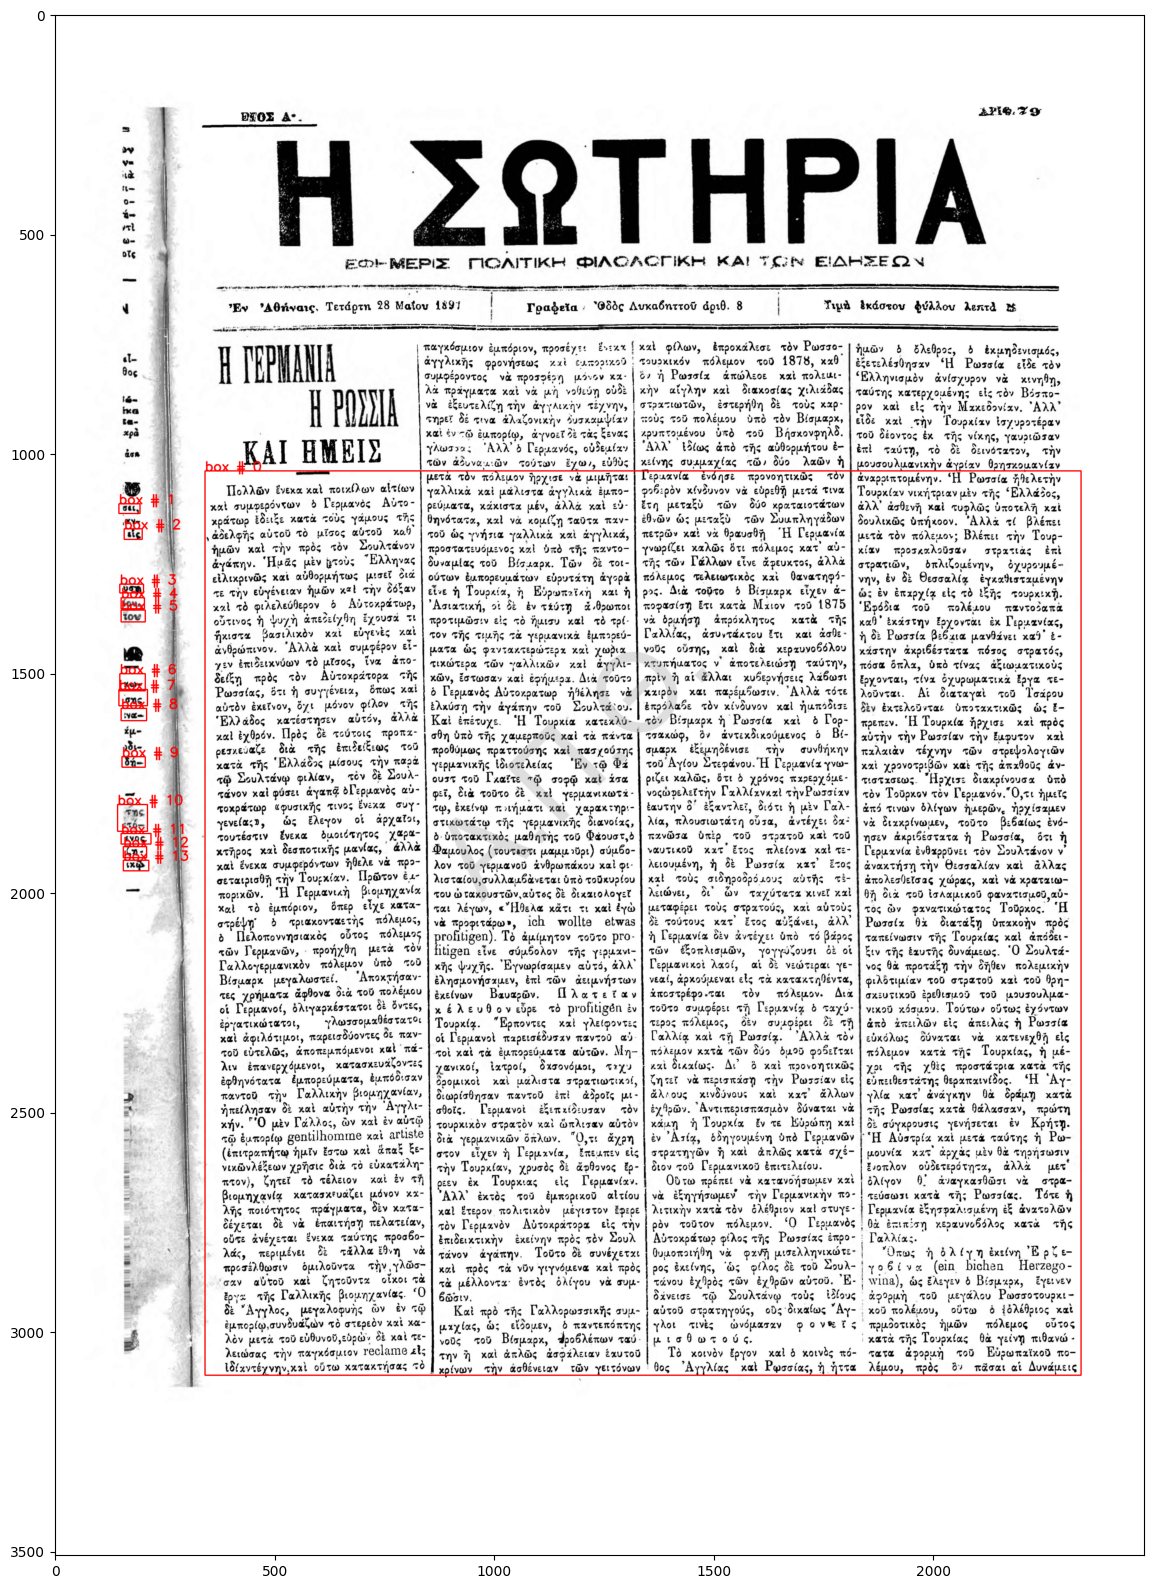

In [165]:
for idx,box in enumerate(bboxes):
    x1,y1, x2, y2, = box
    
    im = cv2.rectangle(im, (x1, y1), (x2, y2), (255, 0, 0), 2)

    
    
        
    # font 
    font = cv2.FONT_HERSHEY_SIMPLEX 
    
    # org 
    org = (x1, y1) 
    
    # fontScale 
    fontScale = 1
    
    # Blue color in BGR 
    color = (255, 0, 0) 
    
    # Line thickness of 2 px 
    thickness = 2
    
    # Using cv2.putText() method 
    im = cv2.putText(im, f'box # {idx}', org, font,  
                    fontScale, color, thickness, cv2.LINE_AA) 
    

plt.figure(figsize=(20, 20))
plt.imshow(im)


In [166]:
x1, y1, x2, y2 = layout_predictions[0].bboxes[0].bbox

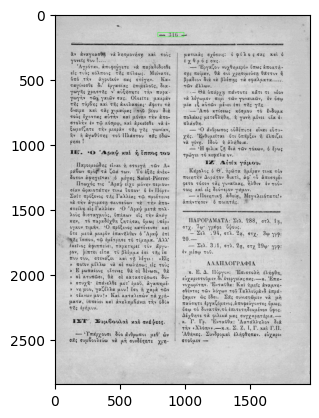

In [21]:
new_img= cv2.rectangle(im, (x1, y1), (x2, y2), (0, 255, 0), 2)
plt.imshow(new_img)